In [2]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Aarav@2207",
    database="retail_store_ml"
)

query = """
SELECT
    `Customer ID`,
    COUNT(DISTINCT Invoice) AS Frequency,
    SUM(Quantity) AS TotalQuantity,
    AVG(Price) AS AvgPrice,
    COUNT(DISTINCT StockCode) AS ProductCount,
    SUM(Quantity * Price) AS TotalSpend
FROM retail
WHERE `Customer ID` IS NOT NULL
  AND Quantity > 0
  AND Price > 0
GROUP BY `Customer ID`;
"""

df = pd.read_sql(query, conn)

conn.close()

df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_86648\592228370.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,Customer ID,Frequency,TotalQuantity,AvgPrice,ProductCount,TotalSpend
0,0,1428,841128.0,6.288362,3301,3.510553e+06
1,12346,1,148430.0,1.040000,1,1.543672e+05
2,12347,7,4916.0,2.644011,103,8.620000e+03
3,12348,4,4682.0,5.764839,22,3.594480e+03
4,12349,1,1262.0,8.289041,73,3.515100e+03


In [3]:
import sklearn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
df.shape

(4339, 6)

In [5]:
df.describe()

,Customer ID,Frequency,TotalQuantity,AvgPrice,ProductCount,TotalSpend
count,4339.00000,4339.000000,4339.000000,4339.000000,4339.000000,4.339000e+03
mean,15296.88177,4.600138,2575.882461,4.468255,62.247753,4.916664e+03
std,1737.20873,22.943499,16246.876555,34.207517,98.510994,5.618530e+04
min,0.00000,1.000000,2.000000,0.122500,1.000000,7.500000e+00
25%,13812.50000,1.000000,320.000000,2.203790,16.000000,6.148600e+02
50%,15299.00000,2.000000,758.000000,2.917778,35.000000,1.349040e+03
75%,16778.50000,5.000000,1986.000000,3.832075,77.000000,3.324120e+03
max,18287.00000,1428.000000,841128.000000,2033.100000,3301.000000,3.510553e+06


In [6]:
X = df[['Frequency','TotalQuantity','AvgPrice',	'ProductCount']]
Y = df['TotalSpend']

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8, random_state=42)

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
model = LinearRegression()

In [11]:
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[1711.22, 1.42, 8.11, -78.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Frequency','TotalQuantity','AvgPrice','ProductCount']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1790
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [12]:
Y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [14]:
print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")

r2_score is : 0.6197329157049565
MSE is : 158641291.54551387
RMSE is : 12595.288466149312
MAE is : 4577.694653749538


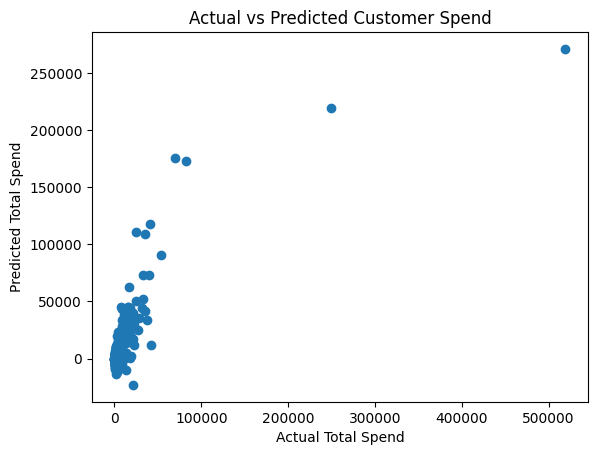

In [15]:
plt.scatter(Y_test, Y_pred)

plt.xlabel("Actual Total Spend")
plt.ylabel("Predicted Total Spend")
plt.title("Actual vs Predicted Customer Spend")

plt.show()

In [16]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

         Feature  Coefficient
0      Frequency  1711.217125
1  TotalQuantity     1.418351
2       AvgPrice     8.111041
3   ProductCount   -78.058480


In [17]:
model.intercept_

np.float64(-1789.718748704573)

In [18]:
from sklearn.linear_model import Ridge

In [19]:
model = Ridge(alpha = 1)

In [20]:
model.fit(X_train , Y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to

In [21]:
Y_pred = model.predict(X_test)

In [22]:
print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")

r2_score is : 0.6197336112177803
MSE is : 158641001.3887867
RMSE is : 12595.276947681092
MAE is : 4577.6892578872885


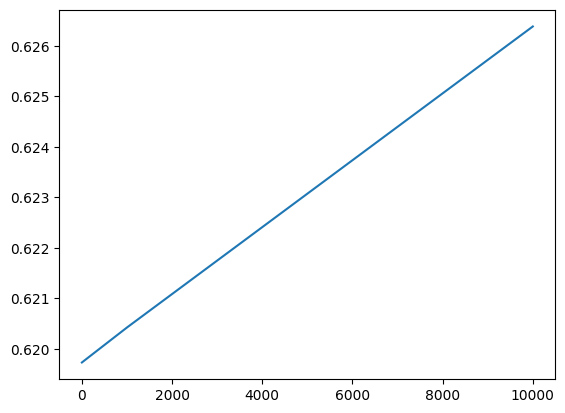

In [23]:
alphas = [0.01, 0.1, 1, 10, 100, 1000, 10000]
r2_scores = []

for alpha in alphas:
    model = Ridge(alpha = alpha)
    model.fit(X_train,Y_train)
    Y_pred = model.predict(X_test)
    score = r2_score(Y_test , Y_pred)
    r2_scores.append(score)

plt.plot(alphas, r2_scores)
plt.show()

In [24]:
from sklearn.linear_model import Lasso

In [25]:
model = Lasso(alpha = 1)

In [26]:
model.fit(X_train,Y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [27]:
Y_pred = model.predict(X_test)

In [28]:
print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")

r2_score is : 0.6197343035079045
MSE is : 158640712.5765177
RMSE is : 12595.265482573906
MAE is : 4577.682640842578


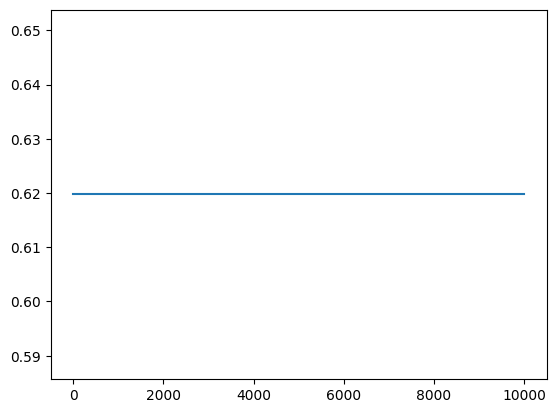

In [29]:
alphas = [0.01, 0.1, 1, 10, 100, 1000, 10000]
r2_scores = []

for alpha in alphas:
    model = Lasso(alpha = alpha)
    model.fit(X_train, Y_train)
    model.predict(X_test)
    score = r2_score(Y_test, Y_pred)
    r2_scores.append(score)

plt.plot(alphas , r2_scores)
plt.show()

In [30]:
best_index = r2_scores.index(max(r2_scores))
best_alpha = alphas[best_index]
model = Lasso(alpha=best_alpha, max_iter=10000)

model.fit(X_train, Y_train)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

         Feature  Coefficient
0      Frequency  1711.217050
1  TotalQuantity     1.418351
2       AvgPrice     8.111035
3   ProductCount   -78.058474


In [31]:
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha = 1, l1_ratio = 0.5, max_iter = 10000)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)

print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")

r2_score is : 0.6197343035079045
MSE is : 158640712.5765177
RMSE is : 12595.265482573906
MAE is : 4577.682640842578


In [32]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state = 42)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)

print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")

r2_score is : 0.6197343035079045
MSE is : 158640712.5765177
RMSE is : 12595.265482573906
MAE is : 4577.682640842578


In [67]:
importance = pd.DataFrame({"features": X.columns, "importance": model.feature_importances_})
importance = importance.sort_values(by = "importance", ascending=False)
print(importance)


        features  importance
1  TotalQuantity    0.483605
3   ProductCount    0.407330
0      Frequency    0.091863
2       AvgPrice    0.017203


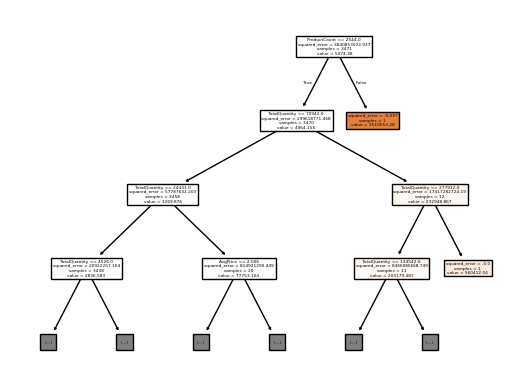

In [41]:
from sklearn.tree import plot_tree
plot_tree(model , feature_names = X.columns, max_depth = 3,filled=True )
plt.show()

In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
params = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

grid = GridSearchCV(DecisionTreeRegressor(random_state = 42), params, scoring = "r2", cv = 5, n_jobs=-1)
grid.fit(X_train, Y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Contr

In [46]:
grid.best_params_

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

In [47]:
grid.best_score_

np.float64(0.6821331794251424)

In [60]:
best_model = grid.best_estimator_
best_model.fit(X_train, Y_train)
Y_pred = best_model.predict(X_test)

print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")


r2_score is : 0.6105128341471644
MSE is : 162487760.7953957
RMSE is : 12747.068713841458
MAE is : 1430.8923271889385


In [59]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators = 200, random_state = 42, n_jobs = -1)

model.fit(X_train , Y_train)
y_pred = model.predict(X_test)

print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")

r2_score is : 0.6105128341471644
MSE is : 162487760.7953957
RMSE is : 12747.068713841458
MAE is : 1430.8923271889385


In [68]:
importance = pd.DataFrame({"features": X.columns, "Importance": model.feature_importances_})
importance = importance.sort_values(by="Importance", ascending=False).reset_index(drop=True)
print(importance)


        features  Importance
0  TotalQuantity    0.483605
1   ProductCount    0.407330
2      Frequency    0.091863
3       AvgPrice    0.017203


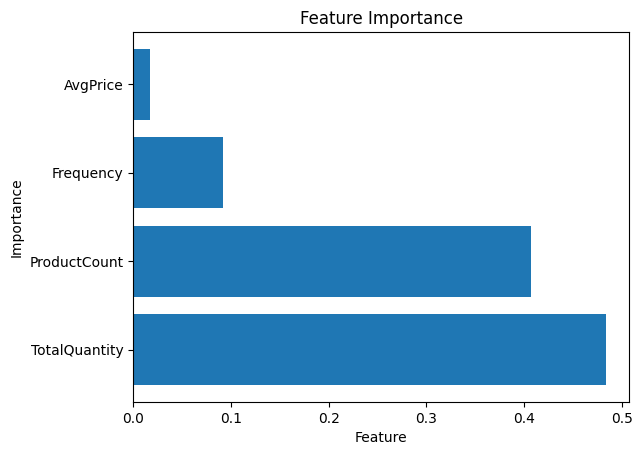

In [71]:
plt.barh(importance['features'], importance['Importance'])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {"n_estimators": [1,5,10,15,20,50,100,150,200]}

grid = GridSearchCV(RandomForestRegressor(random_state = 42), params, scoring="r2", cv=5, n_jobs=-1)
grid.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_estimators': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with 

In [ ]:

print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")

r2_score is : 0.6827730006366082
MSE is : 132341985.3322612
RMSE is : 11503.998667083599
MAE is : 1156.6225614055286


In [75]:
best_model = grid.best_estimator_
best_model.predict(X_test)
print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")


r2_score is : 0.6827730006366082
MSE is : 132341985.3322612
RMSE is : 11503.998667083599
MAE is : 1156.6225614055286


In [76]:
grid.best_score_

np.float64(0.7421446610102553)

In [77]:
grid.best_params_

{'n_estimators': 20}

In [81]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(n_estimators = 100, learning_rate = 0.1, random_state = 42, max_depth= 3)
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")


r2_score is : 0.7731405789741281
MSE is : 94642089.8288643
RMSE is : 9728.416614684236
MAE is : 1138.4708410397757


In [82]:
importance = pd.DataFrame({'Features': X.columns, 'Importance':model.feature_importances_})
importance = importance.sort_values(by = "Importance", ascending = False)
print(importance)

        Features  Importance
1  TotalQuantity    0.475478
3   ProductCount    0.315041
0      Frequency    0.206688
2       AvgPrice    0.002793


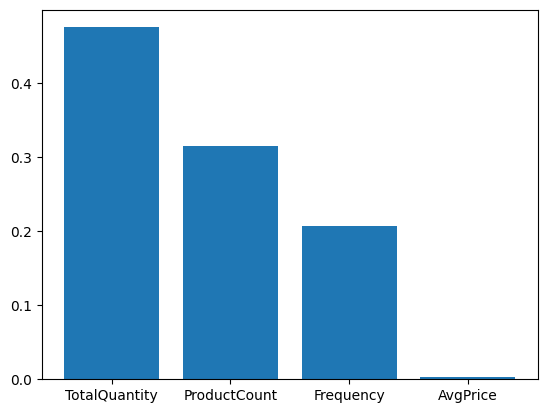

In [86]:
plt.bar(importance['Features'] , importance['Importance'])
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
params = {"n_estimators":[1,5,10,15,20,50,100,150,200] , 'learning_rate':[0.01, 0.05, 0.1], 'max_depth': [2,3,5], 'min_samples_split':[2,5,10]}

grid = GridSearchCV(GradientBoostingRegressor(random_state = 42), params, scoring='r2', cv=5, n_jobs=-1)
grid.fit(X_train, Y_train)


In [90]:
best_model = grid.best_estimator_
best_model.fit(X_train, Y_train)
Y_pred = best_model.predict(X_test)

print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")

r2_score is : 0.7342782733446594
MSE is : 110854816.65197253
RMSE is : 10528.76140160715
MAE is : 1165.3275240030255


In [91]:
grid.best_score_

np.float64(0.7559810012222284)

In [92]:
grid.best_params_

{'learning_rate': 0.05,
 'max_depth': 3,
 'min_samples_split': 10,
 'n_estimators': 200}

In [96]:
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators = 200, learning_rate = 0.05, max_depth = 3, random_state= 42)
model.fit(X_train, Y_train)
Y_pred=model.predict(X_test)
print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")


r2_score is : 0.7026116315370419
MSE is : 124065628.63845481
RMSE is : 11138.475148711103
MAE is : 1555.2275259114601


In [97]:
importance = pd.DataFrame({'Features':X.columns , 'Importance': model.feature_importances_})
importance = importance.sort_values(by="Importance", ascending = False)
print(importance)

        Features  Importance
0      Frequency    0.810047
1  TotalQuantity    0.162377
2       AvgPrice    0.018316
3   ProductCount    0.009261


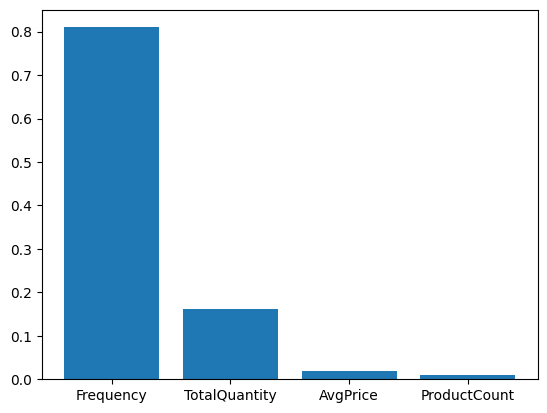

In [98]:
plt.bar(importance['Features'] , importance['Importance'])
plt.show()

In [100]:
from sklearn.model_selection import GridSearchCV
params = {"n_estimators": [100, 200, 300], "learning_rate": [0.01, 0.05, 0.1], "max_depth": [2, 3, 5], "subsample": [0.8, 1.0]}

grid = GridSearchCV(XGBRegressor(random_state = 42 , objective = 'reg:squarederror'), params, scoring='r2', cv=5, n_jobs=-1)        #l2 loss(squared loss) ie [(y-y_not)^2]/n
grid.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose

In [101]:
best_model = grid.best_estimator_
best_model.fit(X_train, Y_train)
Y_pred = best_model.predict(X_test)

print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")

r2_score is : 0.6034162728127341
MSE is : 165448331.673396
RMSE is : 12862.67202696998
MAE is : 2592.948116854481


In [102]:
grid.best_params_

{'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 300, 'subsample': 1.0}

In [103]:
grid.best_score_

np.float64(0.5027885308199206)